## Setup


In [15]:
import sys
from pathlib import Path
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import importlib
import src.baseline_models as bm
importlib.reload(bm)
import src.evaluation as eval
importlib.reload(eval)

<module 'src.evaluation' from '/Users/ranacopty/Desktop/APS360/aps360-movie-flop-predictor/src/evaluation.py'>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from src.baseline_models import (
    create_logistic_regression_pipeline,
    create_majority_baseline)
from src.data_processing import chronological_split
from src.evaluation import (
    evaluate_classifier,
    get_confusion_matrix,
    metrics_to_dataframe)

## Load Processed Data & Chronological Data Split

In [17]:
import pandas as pd

from sklearn.model_selection import train_test_split

df = pd.read_csv(
    project_root / "data/processed/movies_processed.csv",
    parse_dates=["release_date"],
)

# Reserve all 2014+ movies as the chronological test set
development = df[
    df["release_year"] < 2014
].copy()

test = df[
    df["release_year"] >= 2014
].copy()

# Randomly split the pre-2014 development data into train and validation
train, validation = train_test_split(
    development,
    test_size=185,
    stratify=development["flop"],
    random_state=42,
)
# Reset indices for cleaner downstream processing
train = train.reset_index(drop=True)
validation = validation.reset_index(drop=True)
test = test.reset_index(drop=True)
print("Train:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))
print("\nFlop proportions:")
print("Train:", train["flop"].mean())
print("Validation:", validation["flop"].mean())
print("Test:", test["flop"].mean())
assert len(train) == 559
assert len(validation) == 185
assert len(test) == 113

Train: 559
Validation: 185
Test: 113

Flop proportions:
Train: 0.5813953488372093
Validation: 0.5783783783783784
Test: 0.40707964601769914


## Feature Selection

In [18]:
# Automatically collect the one-hot genre columns
genre_features = [
    column
    for column in df.columns
    if column.startswith("genre_")]
# Strictly pre-release numerical/binary features
numeric_features = [
    "budget",
    "runtime",
    "director_success_ratio",
    "director_prior_count",
    "actor_success_ratio",
    "actor_prior_count",
    "is_sequel_or_remake",
    "major_studio",
    *genre_features,
]
# Pre-release categorical features
categorical_features = [
    "original_language",
    "release_season"]
features = numeric_features + categorical_features
target = "flop"
print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)
print("Total features before categorical encoding:", len(features))

Numeric features: 28
Categorical features: ['original_language', 'release_season']
Total features before categorical encoding: 30


In [19]:
missing_features = [
    feature for feature in features
    if feature not in df.columns]
if missing_features:
    raise ValueError(f"Missing features: {missing_features}")
print(df[features + [target]].head())

     budget  runtime  director_success_ratio  director_prior_count  \
0  92620000    153.0                1.000000                   0.0   
1  55000000    143.0               10.000000                   1.0   
2  54000000    127.0               10.000000                   1.0   
3  58000000    127.0                4.525884                   5.0   
4  55000000    107.0                1.000000                   0.0   

   actor_success_ratio  actor_prior_count  is_sequel_or_remake  major_studio  \
0             1.000000                0.0                    0             1   
1             1.000000                0.0                    0             1   
2             6.381250                2.0                    1             1   
3             1.000000                0.0                    0             0   
4             1.261958                1.0                    0             1   

   genre_action  genre_adventure  ...  genre_mystery  genre_romance  \
0             0            

In [20]:
missing_summary = (
    train[features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)
print(missing_summary)

budget                    0
runtime                   0
original_language         0
genre_western             0
genre_war                 0
genre_thriller            0
genre_tv_movie            0
genre_science_fiction     0
genre_romance             0
genre_mystery             0
genre_music               0
genre_horror              0
genre_history             0
genre_foreign             0
genre_fantasy             0
genre_family              0
genre_drama               0
genre_documentary         0
genre_crime               0
genre_comedy              0
genre_animation           0
genre_adventure           0
genre_action              0
major_studio              0
is_sequel_or_remake       0
actor_prior_count         0
actor_success_ratio       0
director_prior_count      0
director_success_ratio    0
release_season            0
dtype: int64


In [21]:
x_train = train[features]
y_train = train[target].astype(int)
x_validation = validation[features]
y_validation = validation[target].astype(int)
x_test = test[features]
y_test = test[target].astype(int)
for split_name, labels in [
    ("Train", y_train),
    ("Validation", y_validation),
    ("Test", y_test)]:
    print(
        f"{split_name}: "
        f"{len(labels)} movies, "
        f"{labels.mean():.1%} flops")

Train: 559 movies, 58.1% flops
Validation: 185 movies, 57.8% flops
Test: 113 movies, 40.7% flops


## Majority-Class Reference

In [22]:
# validation metrics
majority_model = create_majority_baseline()
majority_model.fit(x_train, y_train)
majority_validation_pred = majority_model.predict(x_validation)
majority_validation_metrics = evaluate_classifier(
    y_true=y_validation,
    y_pred=majority_validation_pred)
majority_validation_metrics

{'accuracy': 0.5783783783783784,
 'balanced_accuracy': 0.5,
 'flop_precision': 0.5783783783783784,
 'flop_recall': 1.0,
 'flop_f1': 0.7328767123287672}

## Logistic Regression Baseline

In [23]:
logistic_model = create_logistic_regression_pipeline(
    numeric_features=numeric_features,
    categorical_features=categorical_features)
logistic_model.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
logistic_validation_pred = logistic_model.predict(x_validation)
logistic_validation_prob = logistic_model.predict_proba(x_validation)[:, 1]
logistic_validation_metrics = evaluate_classifier(
    y_true=y_validation,
    y_pred=logistic_validation_pred,
    y_prob=logistic_validation_prob)
logistic_validation_metrics

{'accuracy': 0.6,
 'balanced_accuracy': 0.59339803498682,
 'flop_precision': 0.6601941747572816,
 'flop_recall': 0.6355140186915887,
 'flop_f1': 0.6476190476190476,
 'roc_auc': 0.6843997124370957}

## Quantitative Comparison

In [25]:
comparison = pd.concat(
    [
        metrics_to_dataframe(
            "Majority class",
            majority_validation_metrics,
        ),
        metrics_to_dataframe(
            "Logistic regression",
            logistic_validation_metrics,
        ),
    ],
    ignore_index=True)
metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "flop_precision",
    "flop_recall",
    "flop_f1",
    "roc_auc",
]
comparison[metric_columns] = comparison[
    metric_columns
].round(3)
display(comparison)

,model,accuracy,balanced_accuracy,flop_precision,flop_recall,flop_f1,roc_auc
0,Majority class,0.578,0.500,0.578,1.000,0.733,NaN
1,Logistic regression,0.600,0.593,0.660,0.636,0.648,0.684


## Confusion Matrix

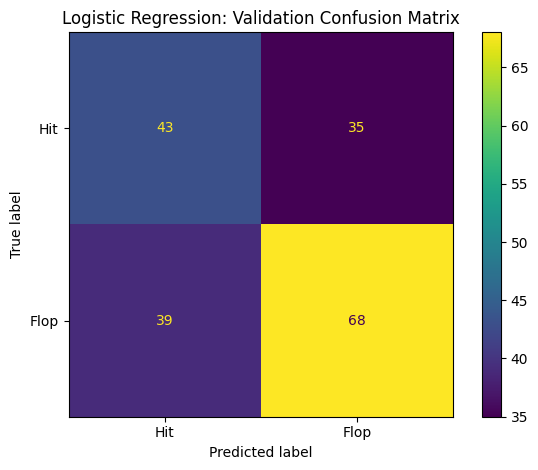

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    logistic_validation_pred,
    labels=[0, 1],
    display_labels=["Hit", "Flop"],
    values_format="d")
plt.title("Logistic Regression: Validation Confusion Matrix")
plt.tight_layout()
plt.show()

## Qualitative Prediction Analysis

In [14]:
# Find all genre indicator columns
genre_features = [
    column
    for column in validation.columns
    if column.startswith("genre_")]
# Keep useful identifying and model-feature columns
validation_predictions = validation[
    [
        "title",
        "release_year",
        "budget",
        "runtime",
        "director",
        "lead_actor",
        "director_success_ratio",
        "director_prior_count",
        "actor_success_ratio",
        "actor_prior_count",
        "original_language",
        "release_season",
        "is_sequel_or_remake",
        "major_studio",
        "flop",
    ]
].copy()

# Convert the one-hot genre columns into readable genre names
validation_predictions["genres"] = validation[
    genre_features
].apply(
    lambda row: ", ".join(
        column.removeprefix("genre_")
        .replace("_", " ")
        .title()
        for column in genre_features
        if row[column] == 1
    ),
    axis=1)

# Add model outputs
validation_predictions["flop_probability"] = (
    logistic_validation_prob)

validation_predictions["predicted_flop"] = (
    logistic_validation_pred)

validation_predictions["correct"] = (
    validation_predictions["flop"]
    == validation_predictions["predicted_flop"])

display(
    validation_predictions[
        [
            "title",
            "release_year",
            "genres",
            "release_season",
            "is_sequel_or_remake",
            "major_studio",
            "flop",
            "flop_probability",
            "predicted_flop",
            "correct",
        ]
    ].head(10)
)

,title,release_year,genres,release_season,is_sequel_or_remake,major_studio,flop,flop_probability,predicted_flop,correct
559,The Book of Eli,2010,"Action, Science Fiction, Thriller",Winter,0,0,1,0.569217,1,True
560,Edge of Darkness,2010,"Crime, Drama, Mystery, Thriller",Winter,0,1,1,0.713362,1,True
561,Percy Jackson & the Olympians: The Lightning T...,2010,"Adventure, Family, Fantasy",Winter,0,0,1,0.452585,0,False
562,From Paris with Love,2010,"Action, Crime, Thriller",Winter,0,0,1,0.608262,1,True
563,Valentine's Day,2010,"Comedy, Romance",Winter,0,1,0,0.381458,0,True
564,Shutter Island,2010,"Drama, Mystery, Thriller",Winter,0,1,0,0.657263,1,False
565,Alice in Wonderland,2010,"Adventure, Family, Fantasy",Spring,0,1,0,0.451288,0,True
566,How to Train Your Dragon,2010,"Adventure, Animation, Family, Fantasy",Spring,0,1,0,0.321295,0,True
567,Green Zone,2010,"Action, Adventure, Drama, Thriller, War",Spring,0,1,1,0.475528,0,False
568,Clash of the Titans,2010,"Action, Adventure, Fantasy",Spring,0,1,1,0.161866,0,False


In [32]:
correct_flops = validation_predictions[
    (validation_predictions["flop"] == 1)
    & (validation_predictions["predicted_flop"] == 1)
].sort_values("flop_probability", ascending=False)
correct_hits = validation_predictions[
    (validation_predictions["flop"] == 0)
    & (validation_predictions["predicted_flop"] == 0)
].sort_values("flop_probability")
false_positives = validation_predictions[
    (validation_predictions["flop"] == 0)
    & (validation_predictions["predicted_flop"] == 1)
].sort_values("flop_probability", ascending=False)
false_negatives = validation_predictions[
    (validation_predictions["flop"] == 1)
    & (validation_predictions["predicted_flop"] == 0)
].sort_values("flop_probability")

In [34]:
examples = pd.concat(
    [
        correct_flops.head(1).assign(
            prediction_type="Correctly predicted flop"
        ),
        correct_hits.head(1).assign(
            prediction_type="Correctly predicted hit"
        ),
        false_positives.head(1).assign(
            prediction_type="False positive"
        ),
        false_negatives.head(1).assign(
            prediction_type="False negative"
        ),
    ],
    ignore_index=True,
)
display(
    examples[
        [
            "prediction_type",
            "title",
            "release_year",
            "flop",
            "flop_probability",
            "predicted_flop",
            "budget",
            "director_success_ratio",
            "actor_success_ratio",
        ]
    ]
)

,prediction_type,title,release_year,flop,flop_probability,predicted_flop,budget,director_success_ratio,actor_success_ratio
0,Correctly predicted flop,Free Birds,2013,1,0.746361,1,55000000,0.224234,2.311002
1,Correctly predicted hit,The Dictator,2012,0,0.127900,0,65000000,10.000000,10.000000
2,False positive,Ghost Rider: Spirit of Vengeance,2011,0,0.727035,1,57000000,2.040729,2.153623
3,False negative,White House Down,2013,1,0.186210,0,150000000,4.134568,8.105296
